- Author: Yousef Al Zeer

## Imports

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn import set_config
set_config(transform_output='pandas')


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label="",
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
fpath = "/content/drive/MyDrive/Intro to ML /Week 3/Core/stroke.csv"
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


## EDA

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [ ]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,1137.000000,1137.000000,1137.000000,1137.000000,1085.000000,1137.000000
mean,36750.933157,0.118734,0.068602,107.664002,29.198065,0.120493
std,21112.281253,0.323617,0.252887,47.618723,7.669615,0.325680
min,77.000000,0.000000,0.000000,55.270000,11.300000,0.000000
25%,17986.000000,0.000000,0.000000,77.600000,24.100000,0.000000
50%,37479.000000,0.000000,0.000000,91.820000,28.500000,0.000000
75%,55410.000000,0.000000,0.000000,113.850000,33.200000,0.000000
max,72918.000000,1.000000,1.000000,266.590000,64.400000,1.000000


- BMI column contains missing values that require imputation. Since the mean is slightly higher than the median, there is slight right-skewness .

- No unrealistic/impossible values were observed across the dataset

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,642
Male,494
Other,1


In [ ]:
df['age'].unique()

array(['31', '13', '18', '65', '4', '28', '64', '62', '26', '63', '50',
       '77', '1', '52', '24', '48', '45', '74', '3', '17', '54', '55',
       '67', '35', '38', '81', '34', '44', '79', '56', '70', '30', '39',
       '29', '80', '59', '51', '19', '43', '71', '0', '23', '53', '78',
       '66', '60', '76', '22', '6', '47', '2', '46', '11', '33', '37',
       '49', '61', '75', '40', '8', '57', '12', '21', '41', '58', '27',
       '20', '68', '42', '5', '69', '9', '36', '25', '82', '73', '32',
       '7', '16', '14', '72', '15', '10', '*82'], dtype=object)

In [ ]:
df['age'] = df['age'].str.strip()
df['age'] = df['age'].str.replace('*' , '')

In [ ]:
df['age'] = df['age'].astype(int)

In [ ]:
df.dtypes

,0
id,int64
gender,object
age,int64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [ ]:
df['ever_married'].value_counts()

,count
ever_married,
Yes,769
No,368


In [ ]:
df['stroke'].value_counts(normalize=True)


,proportion
stroke,
0,0.879507
1,0.120493


- The dataset is imbalanced , with only 12% of instances belonging to the positive class (Stroke)

## PreProcessing

### Train-Test

In [ ]:
cols_drop = ['id']
# Create features matrix and target vector
X = df.drop(columns = [*cols_drop, 'stroke'])
y = df['stroke']
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)
y_train.value_counts(normalize=True).sort_index()

,proportion
stroke,
0,0.879108
1,0.120892


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 852 entries, 72 to 1126
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             852 non-null    object 
 1   age                852 non-null    int64  
 2   hypertension       852 non-null    int64  
 3   heart_disease      852 non-null    int64  
 4   ever_married       852 non-null    object 
 5   work_type          852 non-null    object 
 6   Residence_type     852 non-null    object 
 7   avg_glucose_level  852 non-null    float64
 8   bmi                812 non-null    float64
 9   smoking_status     852 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 73.2+ KB


### Numeric

In [ ]:
# Numerical Prepprocessing Pipeline
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')


### Categorical

In [ ]:
# Categorical Preprocessing Pipeline

ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
impute_na = SimpleImputer(strategy='constant', fill_value = "Missing")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


In [ ]:
preprocessor = ColumnTransformer([num_tuple, ohe_tuple], verbose_feature_names_out=False)

## 1) Logistic Regression

### Default Model

In [ ]:
logreg = LogisticRegression(random_state=42)
logreg_pipe = make_pipeline(preprocessor, logreg)
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       749
           1       0.48      0.15      0.22       103

    accuracy                           0.88       852
   macro avg       0.69      0.56      0.58       852
weighted avg       0.84      0.88      0.85       852



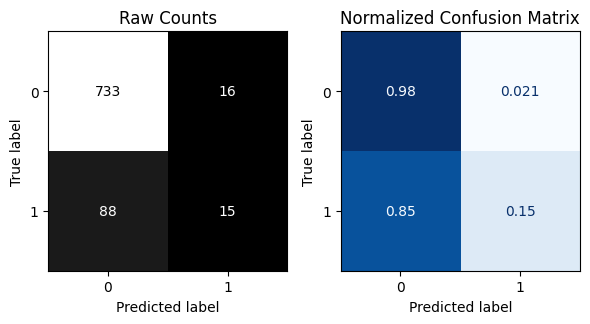


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.29      0.06      0.10        34

    accuracy                           0.87       285
   macro avg       0.59      0.52      0.51       285
weighted avg       0.81      0.87      0.83       285



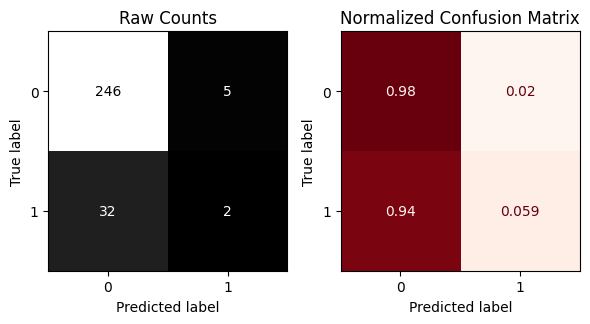

In [ ]:
# Evaluate the default model
evaluate_classification(logreg_pipe, X_train, y_train, X_test, y_test)

### Tuned Model

In [ ]:
# Elasticnet Tuning
elasticnet_params = {
    'logisticregression__solver': ['saga'],
    'logisticregression__penalty': ['elasticnet'],
    'logisticregression__l1_ratio': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    'logisticregression__class_weight': [None, 'balanced']
}

# L2 Tuning
l2_params = {
    'logisticregression__solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'logisticregression__penalty': ['l2'],
    'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    'logisticregression__class_weight': [None, 'balanced']
}

# # L1 Tunings
l1_params = {
    'logisticregression__solver': ['liblinear', 'saga'],
    'logisticregression__penalty': ['l1'],
    'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    'logisticregression__class_weight': [None, 'balanced']
}

# No Penalty
none_params = {
    'logisticregression__solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'logisticregression__penalty': [None],
    'logisticregression__class_weight': [None, 'balanced']
}

param_grid = [elasticnet_params, l2_params, l1_params, none_params]

In [ ]:
gs = GridSearchCV(logreg_pipe, param_grid, cv=3 , verbose = 5, n_jobs = -1,scoring='recall_macro')
# Fit the gs on the training data only
gs.fit(X_train, y_train)
gs.best_params_

Fitting 3 folds for each of 176 candidates, totalling 528 fits


{'logisticregression__C': 0.01,
 'logisticregression__class_weight': 'balanced',
 'logisticregression__penalty': 'l1',
 'logisticregression__solver': 'saga'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.72      0.82       749
           1       0.29      0.84      0.43       103

    accuracy                           0.73       852
   macro avg       0.63      0.78      0.63       852
weighted avg       0.89      0.73      0.78       852



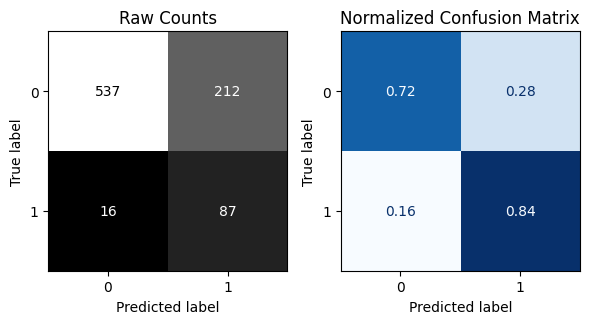


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.72      0.83       251
           1       0.29      0.85      0.43        34

    accuracy                           0.73       285
   macro avg       0.63      0.79      0.63       285
weighted avg       0.89      0.73      0.78       285



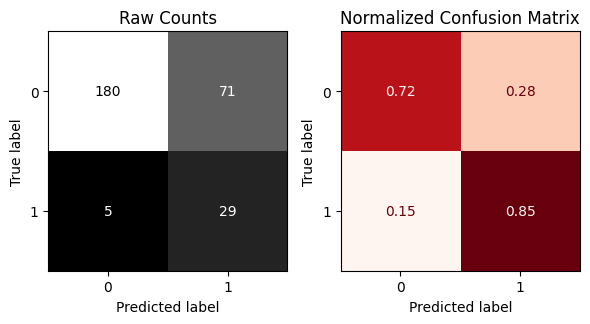

In [ ]:
opt_model = gs.best_estimator_
evaluate_classification(opt_model, X_train, y_train, X_test, y_test)

Based on the GridSearchCV results, the best tuned model was achieved using the following hyperparameters:

* **C:** `0.01`
* **Penalty:** `l1` (Lasso)
* **Solver:** `saga`
* **Class Weight:** `balanced`

---

### Metrics Comparison



| Model Status | Macro Recall (Test) | Recall (Class 1) | F1-Score (Class 1) | Accuracy (Test) |
| :--- | :---: | :---: | :---: | :---: |
| **Default** | 0.52 | 0.06 | 0.10 | **0.87** |
| **Tuned (Best)** | **0.79** | **0.85** | **0.43** | 0.73 |

---


- The tuned model is clearly the best performer as it effectively handled the data imbalance that the default model ignored.

- The model is now much more balanced and generalizes well to unseen data .


- We achieved a huge jump in Recall (from 0.06 to 0.85), meaning the model can now actually detect most stroke cases instead of missing them. which is the primary goal of our task .

## 2) K-nearest neighbors

### Default Model

In [ ]:
knn = KNeighborsClassifier()
knn_pipe = make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       749
           1       0.61      0.24      0.35       103

    accuracy                           0.89       852
   macro avg       0.76      0.61      0.64       852
weighted avg       0.87      0.89      0.87       852



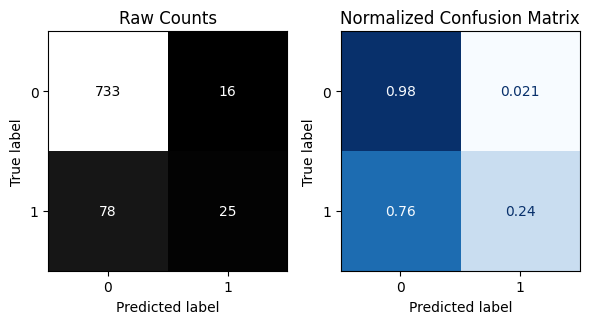


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       251
           1       0.22      0.06      0.09        34

    accuracy                           0.86       285
   macro avg       0.55      0.52      0.51       285
weighted avg       0.81      0.86      0.83       285



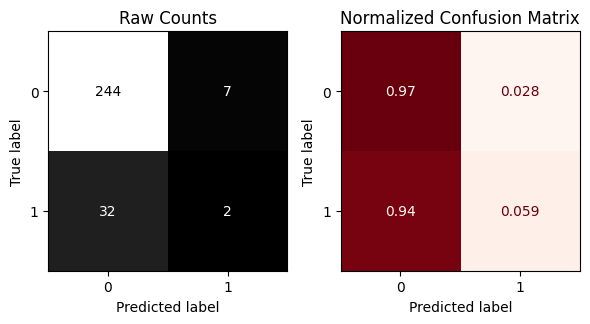

In [ ]:
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

### Tuned Model

In [ ]:
knn_param_grid = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 41, 51],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

In [ ]:
gs = GridSearchCV(knn_pipe, knn_param_grid, cv=3 , verbose = 5, n_jobs = -1,scoring='recall_macro')
# Fit the gs on the training data only
gs.fit(X_train, y_train)
gs.best_params_

Fitting 3 folds for each of 60 candidates, totalling 180 fits


{'kneighborsclassifier__metric': 'manhattan',
 'kneighborsclassifier__n_neighbors': 3,
 'kneighborsclassifier__weights': 'uniform'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       749
           1       0.74      0.41      0.53       103

    accuracy                           0.91       852
   macro avg       0.83      0.69      0.74       852
weighted avg       0.90      0.91      0.90       852



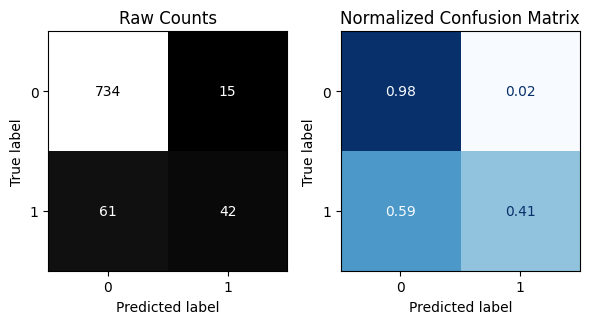


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       251
           1       0.24      0.12      0.16        34

    accuracy                           0.85       285
   macro avg       0.56      0.53      0.54       285
weighted avg       0.81      0.85      0.83       285



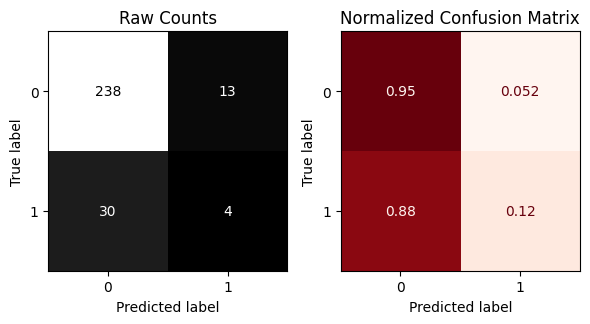

In [ ]:
opt_model = gs.best_estimator_
evaluate_classification(opt_model, X_train, y_train, X_test, y_test)

Based on the GridSearchCV results, the best tuned model was achieved using the following hyperparameters:

* **n_neighbors:** `3`
* **weights:** `uniform`
* **metric:** `manhattan`

---

### Metrics Comparison

| Model Status | Macro Recall (Test) | Recall (Class 1) | F1-Score (Class 1) | Accuracy (Test) |
| :--- | :---: | :---: | :---: | :---: |
| **Default** | 0.52 | 0.06 | 0.09 | **0.86** |
| **Tuned (Best)** | **0.56** | **0.12** | **0.16** | 0.85 |

---


- The tuned model is the better performer because it managed to find a better balance between the classes compared to the default settings.

- The model generalizes well to unseen data .

- We achieved an improvement in Recall (from 0.06 to 0.12) by using a smaller neighbor count and Manhattan distance

## Random Forest

### Default Model

In [ ]:
rf_clf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf_clf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



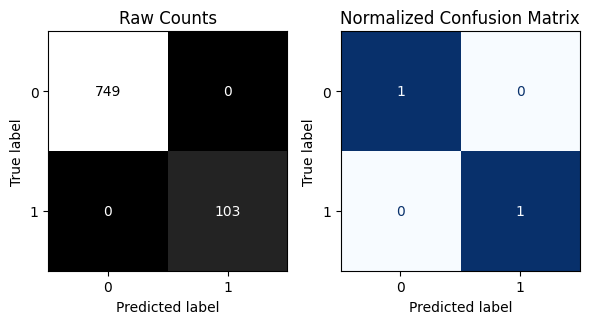


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.14      0.03      0.05        34

    accuracy                           0.86       285
   macro avg       0.51      0.50      0.49       285
weighted avg       0.79      0.86      0.82       285



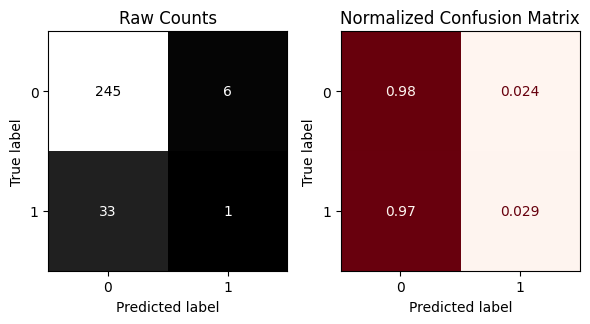

In [ ]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

### Tuned Model

In [ ]:
rf_grid = {
    'randomforestclassifier__n_estimators': [100 ,200, 250],
    'randomforestclassifier__min_samples_leaf': [5, 6, 7],
    'randomforestclassifier__max_depth': [20 , 30, 40 , None],
    'randomforestclassifier__max_features': ['log2', 'sqrt' ,  0.6],
    'randomforestclassifier__class_weight': ['balanced', None]
}

In [ ]:
gs = GridSearchCV(rf_pipe, rf_grid, cv=3 , verbose = 5, n_jobs = -1,scoring='recall_macro')
# Fit the gs on the training data only
gs.fit(X_train, y_train)
gs.best_params_

Fitting 3 folds for each of 216 candidates, totalling 648 fits


{'randomforestclassifier__class_weight': 'balanced',
 'randomforestclassifier__max_depth': 20,
 'randomforestclassifier__max_features': 'log2',
 'randomforestclassifier__min_samples_leaf': 6,
 'randomforestclassifier__n_estimators': 200}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       749
           1       0.48      0.88      0.63       103

    accuracy                           0.87       852
   macro avg       0.73      0.88      0.77       852
weighted avg       0.92      0.87      0.89       852



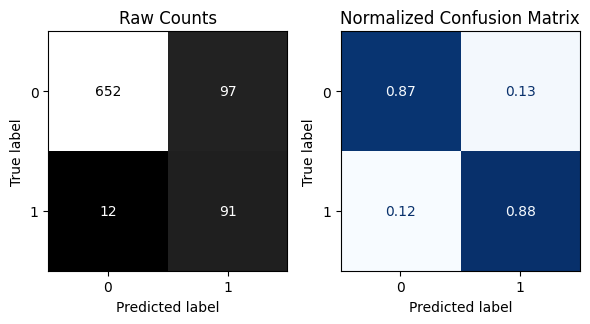


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.84      0.89       251
           1       0.32      0.53      0.40        34

    accuracy                           0.81       285
   macro avg       0.62      0.69      0.64       285
weighted avg       0.86      0.81      0.83       285



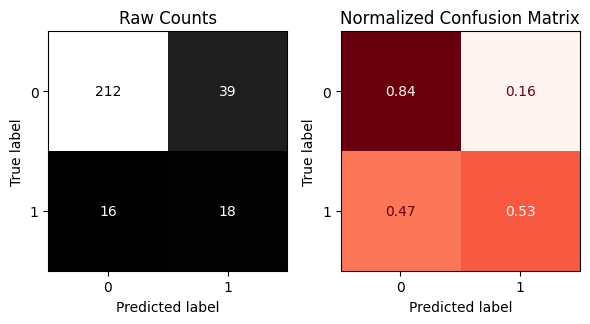

In [ ]:
opt_model = gs.best_estimator_
evaluate_classification(opt_model, X_train, y_train, X_test, y_test)


Based on the GridSearchCV results, the best tuned model was achieved using the following hyperparameters:

* **n_estimators:** `200`
* **max_depth:** `20`
* **max_features:** `log2`
* **min_samples_leaf:** `6`
* **class_weight:** `balanced`

---

### Metrics Comparison

| Model Status | Macro Recall (Test) | Recall (Class 1) | F1-Score (Class 1) | Accuracy (Test) |
| :--- | :---: | :---: | :---: | :---: |
| **Default RF** | 0.50 | 0.03 | 0.05 | **0.86** |
| **Tuned RF** | **0.69** | **0.53** | **0.40** | 0.81 |

---

- The tuned model is clearly the superior performer.

- The model generalizes well to unseen data .

- We achieved a massive improvement in Recall (from 0.03 to 0.53) by utilizing class_weight='balanced' and optimizing the tree depth


## Evaluation

**Recommendation:**
I recommend the **Tuned Logistic Regression model** for production.

- Primary Metric of Choice: **Recall**

- In stroke prediction, the cost of a "False Negative" (missing a stroke) is life threatening and much higher than "False Positive" (False Warning).Therefore, Recall is the most critical metric. Logistic Regression achieved the highest Recall on the test set (0.85)

- Although the Tuned Random Forest offers a slightly higher Precision, the substantial gap in Recall compared to the Logistic Regression model is too large to overlook.

- The performance of Logistic Regression was very consistent between the training and testing sets , which indicates excellent generalization and reliability for deployment.